In [1]:
import sys
import os
import jax
import jax.numpy as np
import jax.tree as jtu
import jax.random as jr
import matplotlib.pyplot as plt
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable

# Basic jax import
jax.config.update("jax_enable_x64", True)


# Check if running on remote, and set directory to where notebook is run
if jax.devices()[0].platform == "gpu":
    os.chdir("code/amigo_project/notebooks/calibration")

# Add parent directories
paths = [os.path.abspath(os.path.join(os.getcwd(), path)) for path in ['..', "../.."]]
for path in paths:
    if path not in sys.path:
        sys.path.insert(0, path)
        
# Plotting set up
%matplotlib inline
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["figure.dpi"] = 120

inferno = mpl.colormaps["inferno"]
seismic = mpl.colormaps["seismic"]
coolwarm = mpl.colormaps["coolwarm"]
inferno.set_bad("k", 0.5)
seismic.set_bad("k", 0.5)
coolwarm.set_bad("k", 0.5)


def merge_cbar(ax):
    return make_axes_locatable(ax).append_axes("right", size="5%", pad=0.0)

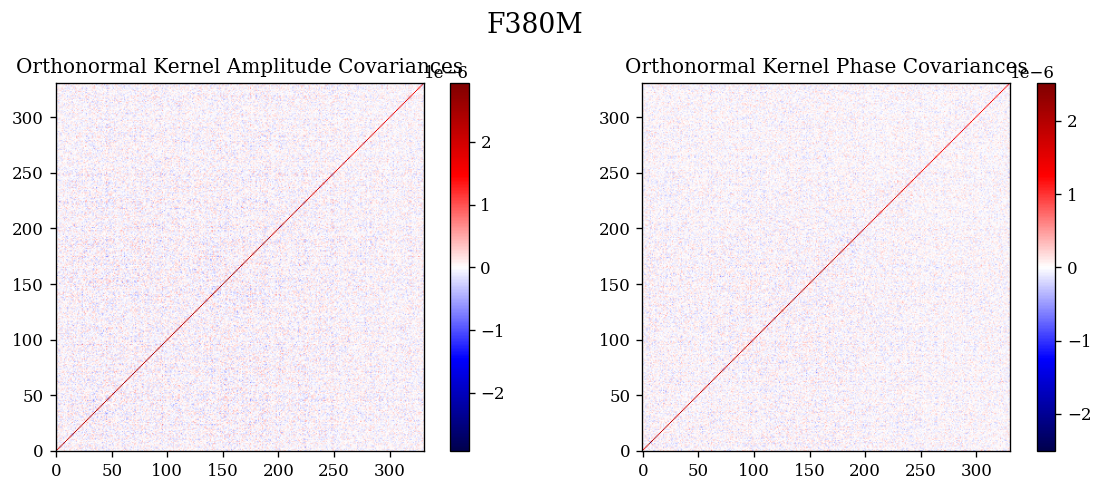

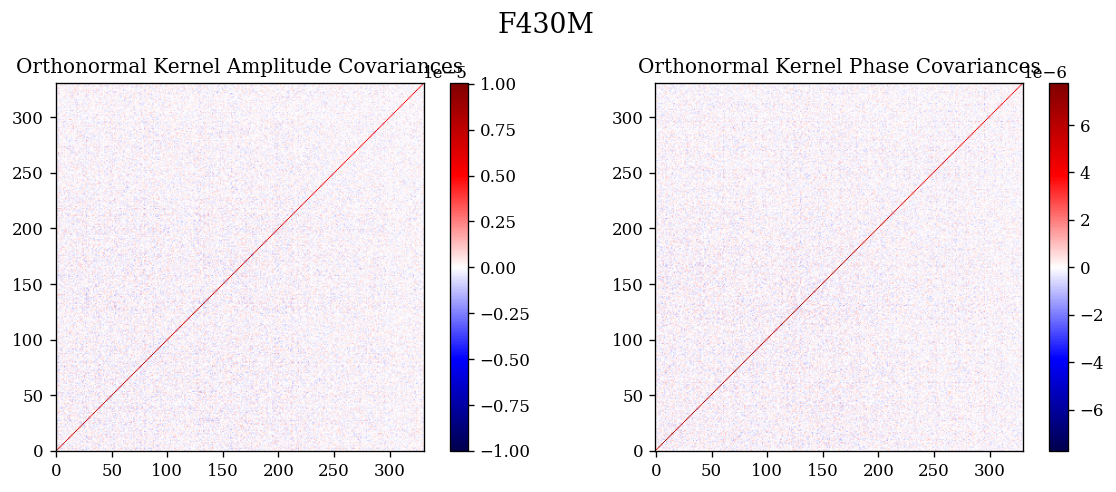

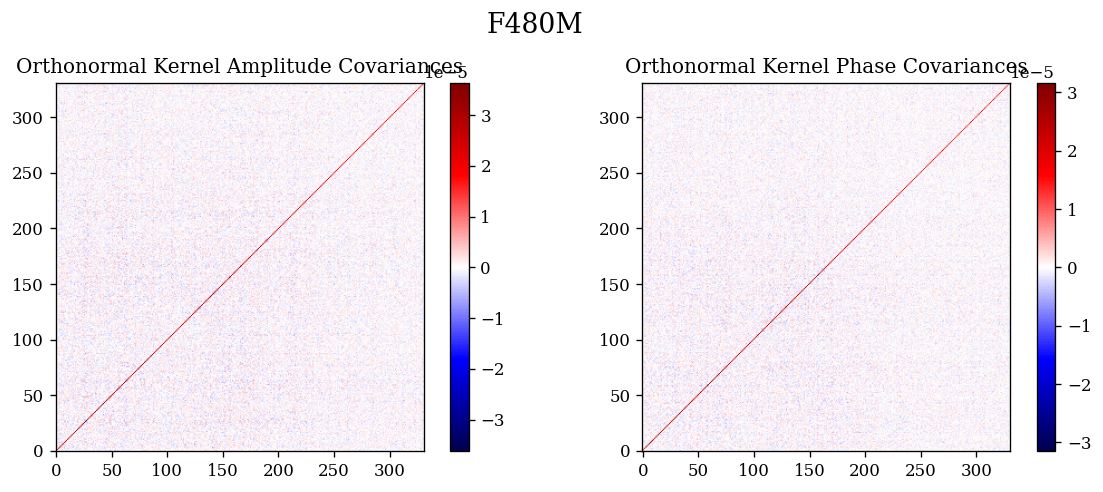

In [2]:
filters = ["F380M", "F430M", "F480M"]

cal_vis_outputs = {}
for filt in filters:
    cal_vis = np.load(f"../../GPU_files/temp/1843/{filt}.npy", allow_pickle=True).item()

    vis = cal_vis["K_vis"]
    phi = cal_vis["K_phi"]
    vis_cov = cal_vis["K_vis_cov"]
    phi_cov = cal_vis["K_phi_cov"]

    vis_vals, vis_vecs = np.linalg.eig(vis_cov)
    phi_vals, phi_vecs = np.linalg.eig(phi_cov)

    vis_vals, vis_vecs = vis_vals.real, vis_vecs.real
    phi_vals, phi_vecs = phi_vals.real, phi_vecs.real

    new_vis_cov = np.dot(vis_vecs, np.dot(vis_cov, np.linalg.inv(vis_vecs)))
    new_phi_cov = np.dot(phi_vecs, np.dot(phi_cov, np.linalg.inv(phi_vecs)))

    new_vis = np.dot(vis_vecs, vis)
    new_phi = np.dot(phi_vecs, phi)

    cal_vis["vis"] = new_vis
    cal_vis["phi"] = new_phi
    cal_vis["vis_cov"] = new_vis_cov
    cal_vis["phi_cov"] = new_phi_cov
    cal_vis["K_vis_proj"] = vis_vecs
    cal_vis["K_phi_proj"] = phi_vecs

    cal_vis_outputs[filt] = cal_vis

    plt.figure(figsize=(10, 4))
    plt.suptitle(filt, fontsize=16)

    v = np.nanmax(np.abs(new_vis_cov))
    plt.subplot(1, 2, 1)
    plt.title("Orthonormal Kernel Amplitude Covariances")
    plt.imshow(new_vis_cov, seismic, vmin=-v, vmax=v)
    plt.colorbar()

    v = np.nanmax(np.abs(new_phi_cov))
    plt.subplot(1, 2, 2)
    plt.title("Orthonormal Kernel Phase Covariances")
    plt.imshow(new_phi_cov, seismic, vmin=-v, vmax=v)
    plt.colorbar()

    plt.tight_layout()
    plt.show()

In [3]:
import equinox as eqx
import zodiax as zdx


class AmigoOIData(zdx.Base):
    # Coordinates
    u: np.ndarray
    v: np.ndarray
    wavel: np.ndarray
    parang: np.ndarray

    # Latent Kernel Visibilities
    vis: np.ndarray
    d_vis: np.ndarray

    # Latent Kernel Phases
    phi: np.ndarray
    d_phi: np.ndarray

    # Latent space projection matrices
    vis_mat: np.ndarray  # Latent -> Pixel
    phi_mat: np.ndarray  # Latent -> Pixel
    vis_mat_inv: np.ndarray  # Pixel -> Latent
    phi_mat_inv: np.ndarray  # Pixel -> Latent

    # Kernel projection matrices
    K_vis_mat: np.ndarray  # Latent -> Null
    K_phi_mat: np.ndarray  # Latent -> Null
    K_vis_mat_inv: np.ndarray  # Null -> Latent
    K_phi_mat_inv: np.ndarray  # Null -> Latent

    # Orthonormal Kernel projection matrices
    K_vis_proj: np.ndarray  # Kernel -> Orthonormal
    K_phi_proj: np.ndarray  # Kernel -> Orthonormal
    K_vis_proj_inv: np.ndarray  # Orthonormal -> Kernel
    K_phi_proj_inv: np.ndarray  # Orthonormal -> Kernel

    def __init__(self, oi_data):
        """
        Default should have vis, phi as their _latent_ values
        """
        self.u = -np.array(oi_data["u"], dtype=float)
        self.v = -np.array(oi_data["v"], dtype=float)
        self.wavel = np.array(oi_data["wavel"], dtype=float)
        self.parang = np.array(oi_data["parang"], dtype=float)

        # Visibilities
        self.vis = np.array(oi_data["vis"], dtype=float)
        self.phi = np.array(oi_data["phi"], dtype=float)

        # Uncertainties
        self.d_phi = np.diag(oi_data["phi_cov"]) ** 0.5
        self.d_vis = np.diag(oi_data["vis_cov"]) ** 0.5

        # Latent space
        self.vis_mat = np.array(oi_data["vis_mat"], dtype=float)
        self.phi_mat = np.array(oi_data["phi_mat"], dtype=float)
        self.vis_mat_inv = np.linalg.pinv(self.vis_mat)
        self.phi_mat_inv = np.linalg.pinv(self.phi_mat)

        # Kernel space
        self.K_vis_mat = np.array(oi_data["K_vis_mat"], dtype=float)
        self.K_phi_mat = np.array(oi_data["K_phi_mat"], dtype=float)
        self.K_vis_mat_inv = np.linalg.pinv(self.K_vis_mat)
        self.K_phi_mat_inv = np.linalg.pinv(self.K_phi_mat)

        # Orthonormal Kernel space
        self.K_vis_proj = np.array(oi_data["K_vis_proj"], dtype=float)
        self.K_phi_proj = np.array(oi_data["K_phi_proj"], dtype=float)
        self.K_vis_proj_inv = np.linalg.pinv(self.K_vis_proj)
        self.K_phi_proj_inv = np.linalg.pinv(self.K_phi_proj)

    def latent_to_pixel(self, latent_vis):
        return np.dot(latent_vis, self.V)

    def latent_to_null(self, latent_vis):
        # return np.dot(latent_vis, self.K)
        return np.dot(self.K, latent_vis)

    def pixel_to_latent(self, vis_vec):
        return np.dot(vis_vec, self.V_inv)

    def null_to_latent(self, K_vis):
        return np.dot(K_vis, self.K_inv)

    def flatten_data(self):
        """Flatten closure phases and uncertainties."""
        vis_vec = np.concatenate([self.vis, self.phi])
        vis_err = np.concatenate([self.d_vis, self.d_phi])
        return vis_vec, vis_err

    def flatten_model(self, cvis):
        """
        cvis: complex visibilities from model
        Flatten model visibilities and phases.
        """
        # Project the visibilities to the latent
        log_cvis = np.log(cvis)
        log_vis, phi = log_cvis.real, log_cvis.imag
        log_vis = np.dot(log_vis, self.vis_mat_inv)
        phi = np.dot(phi, self.phi_mat_inv)

        # Project the visibilities to the kernel space
        K_vis = np.dot(self.K_vis_mat, log_vis)
        K_phi = np.dot(self.K_phi_mat, phi)

        # Project the visibilities to the orthonormal kernel space
        vis = np.dot(self.K_vis_proj, K_vis)
        phi = np.dot(self.K_phi_proj, K_phi)
        return np.concatenate([vis, phi])

    def model(self, model_object):
        """
        Compute the model visibilities and phases for the given model object.
        """
        cvis = model_object.model(self.u, self.v, self.wavel)
        return self.flatten_model(cvis)

    # Overwrite this, it was a mistake from the beginning
    def __repr__(self):
        return eqx.Module.__repr__(self)

In [4]:
import jax.numpy as np
import optimistix as optx
from jax import vmap
import dLux.utils as dlu
from jax.scipy.stats import norm


@eqx.filter_jit
def loglike(values, params, data_obj, model_class):
    """
    Abstract log-likelihood function for a given model class and data object, assuming
    Gaussian errors.

    Parameters
    ----------
    values : array-like
        Values of the model parameters.
    params : list
        List of parameter names.
    data_obj : OIData
        Object containing the data to be fitted.
    model_class : class
        Model class to be fitted to the data.

    Returns
    -------
    float
        Log-likelihood value.
    """
    model_data = data_obj.model(model_class(**dict(zip(params, values))))
    data, errors = data_obj.flatten_data()
    return norm.logpdf(model_data, loc=data, scale=errors).sum()


def likelihood_grid(data_obj, model_class, samples_dict, n_batch=50):
    """
    Function to vmap a likelihood function over a grid of parameter values provided in
    a dictionary.

    Parameters
    ----------
    data_obj : OIData
        Object containing the data to be fitted.
    model_class : class
        Model class to be fitted to the data.
    samples_dict: dict
        Dictionary of parameter names and values to be fitted to the data.

    Returns
    -------
    array-like
        Log-likelihood values over the grid of parameter values.
    """

    params = list(samples_dict.keys())
    samples = samples_dict.values()
    vals = np.array(np.meshgrid(*samples))
    vals_vec = vals.reshape((len(vals), -1)).T

    # NOTE: Is this dimensionally robust? How do we know what which output axis is
    # which? Seems it could be ordered by the dictionary key
    fn = eqx.filter_jit(
        vmap(lambda values: loglike(values, params, data_obj, model_class))
    )
    # return batched_fn(fn, vals_vec, n_batch=n_batch)

    batches = np.array_split(vals_vec, n_batch)
    out = []
    for batch in batches:
        out.append(fn(batch))
    out = np.concatenate(out)
    return out.reshape(vals.shape[1:])  # check the shapes output here


def optimized_contrast_grid(data_obj, model_class, samples_dict, n_batch=50):
    """
    Function to optimize the contrast of a model over a grid of parameter values
    provided in a dictionary.

    Parameters
    ----------
    best_contrast_indices : array-like
        Indices of the best contrast values in a grid calculated with likelihood_grid.
    data_obj : OIData
        Object containing the data to be fitted.
    model_class : class
        Model class to be fitted to the data.
    samples_dict: dict
        Dictionary of parameter names and values to be fitted to the data.

    Returns
    -------
    array-like
        Optimized contrast values over the grid of parameter values.

    """
    params = list(samples_dict.keys())

    loglike_im = likelihood_grid(data_obj, model_class, samples_dict, n_batch=n_batch)
    # loglike_im = fn(vals_vec).reshape(vals.shape[1:]) # check the shapes output here
    best_contrast_indices = np.argmax(loglike_im, axis=2)

    # then do optimization to fine tune the contrast
    coords = [samples_dict[key] for key in ["dra", "ddec"]]
    ras, decs = np.meshgrid(*coords)
    vals = np.array([samples_dict["flux"][best_contrast_indices].T, decs, ras])
    vals_vec = vals.reshape((len(vals), -1)).T

    to_optimize = lambda flux, dra_inp, ddec_inp: -loglike(
        [dra_inp, ddec_inp, flux], params, data_obj, model_class
    )
    bestcon = lambda flux, dra, ddec: optx.compat.minimize(
        to_optimize,
        x0=np.array([flux]),
        args=(np.array(dra), np.array(ddec)),
        method="BFGS",
        options={"maxiter": 100},
    ).x

    fn = eqx.filter_jit(vmap(lambda values: bestcon(*values)))
    # return batched_fn(fn, vals_vec, n_batch=n_batch).T  # check the shapes output here

    batches = np.array_split(vals_vec, n_batch)
    out = []
    for batch in batches:
        out.append(fn(batch))
    out = np.concatenate(out)
    return out.reshape(vals.shape[1:]).T  # check the shapes output here

In [5]:
from drpangloss.models import BinaryModelCartesian


def fit_oi_data(
    grid,
    oi_data,
    amp_scale=1.0,
    phi_scale=1.0,
    n_batch=50,
    obj=AmigoOIData,
):
    # Scale the errors
    oi_obj = obj(oi_data)
    oi_obj = oi_obj.multiply("d_vis", amp_scale)
    oi_obj = oi_obj.multiply("d_phi", phi_scale)

    # NOTE: The log-likelihood image seems to come out (Dec, RA), so we _dont_ need to
    # transpose the output
    # Log-likelihood
    loglike_im = likelihood_grid(oi_obj, BinaryModelCartesian, grid, n_batch=n_batch)
    loglike_im = loglike_im.max(axis=2)

    # NOTE: The Contrast image seems to come out (RA, Dec), so we transpose the output
    # Best contrast
    contrast_im = optimized_contrast_grid(
        oi_obj, BinaryModelCartesian, grid, n_batch=n_batch
    )
    contrast_im = np.where(contrast_im < 0, 0, contrast_im).T

    # # Get the FoVs
    r_bls = np.hypot(oi_data["u"], oi_data["v"])
    min_bls, max_bls = r_bls.min(), r_bls.max()
    min_fov = 1e3 * dlu.rad2arcsec(oi_data["wavel"] / (2 * max_bls))
    max_fov = 1e3 * dlu.rad2arcsec(oi_data["wavel"] / (2 * min_bls))

    # Mask the fov
    rs = np.hypot(*np.meshgrid(grid["dra"], grid["ddec"]))
    r_max = np.minimum(max_fov, 2 * grid["dra"].max())
    rmask = (rs > min_fov / 2) & (rs <= r_max / 2)

    # rmask = (rs > 200 / 2) & (rs <= r_max / 2)
    loglike_im = np.where(rmask, loglike_im, np.nan)
    contrast_im = np.where(rmask, contrast_im, np.nan)

    # Return the images
    return loglike_im, contrast_im, (min_fov, max_fov)

In [ ]:

# Samples
n = 60
size = 350  # mas

  0%|          | 0/3 [00:00<?, ?it/s]

RA: -46.22
Dec: 189.08
F380M: -inf
F430M: -inf
F480M: -3.32


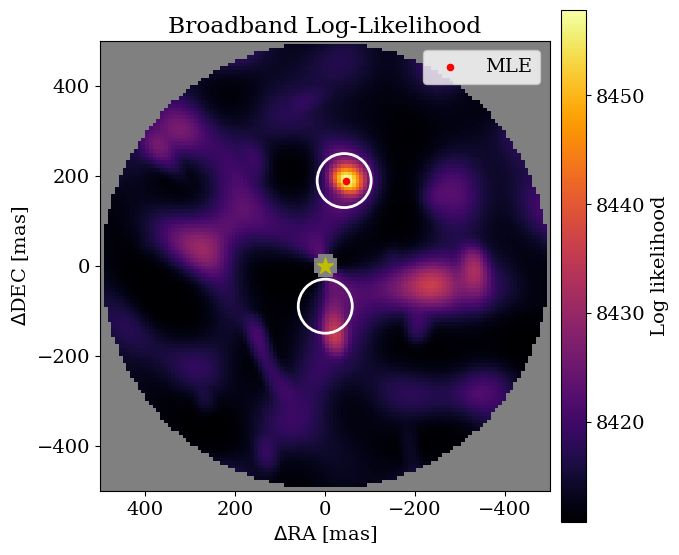

In [7]:
import dLux.utils as dlu
import matplotlib.patches as patches
from amigo.misc import tqdm

# # Values from here, Fig 16: 
# # https://www.stsci.edu/files/live/sites/www/files/home/jwst/documentation/_documents/jwst-science-performance-report.pdf
# pa, sep = -79.4, 325.6
# ra = sep * np.sin(dlu.deg2rad(pa))
# dec = sep * np.cos(dlu.deg2rad(pa))
binaries = [
    (-43, 189),  # Ra, Dec
    (-1, -90),  # Ra, Dec
]


# Samples
n = 120
size = 500 # mas
RAs = np.linspace(size, -size, n)
Decs = np.linspace(-size, size, n)
fluxes = np.linspace(-6, 0, n)
grid = {"dra": RAs, "ddec": Decs, "flux": 10 ** fluxes}


# Calculate the log-likelihoods
loglike_ims, contrast_ims, fovs = {}, {}, {}
for filt, oi_data in tqdm(cal_vis_outputs.items()):
    loglike_im, contrast_im, fov = fit_oi_data(
        grid, oi_data, 
        amp_scale=1,
        phi_scale=1,
        n_batch=500, 
    )
    loglike_ims[filt] = loglike_im
    contrast_ims[filt] = contrast_im
    fovs[filt] = fov

# Get the MLEs
loglike_im = np.array(jtu.leaves(loglike_ims)).sum(axis=0)
dec_ind, ra_ind = np.where(loglike_im == np.nanmax(loglike_im))
contrast_mles = jtu.map(lambda x: np.log10(x[*dec_ind, *ra_ind]), contrast_ims)
ra_mle, dec_mle = RAs[*ra_ind], Decs[*dec_ind]

# print("(RA, Dec)")
print(f"RA: {ra_mle:.2f}")
print(f"Dec: {dec_mle:.2f}")
[print(f"{filt}: {contrast:.2f}") for filt, contrast in contrast_mles.items()]


#
extent = (RAs[0], RAs[-1], Decs[0], Decs[-1])
make_circle = lambda position, diameter, **kwargs: patches.Circle(
    position, diameter / 2, color="w", fill=False, linewidth=2, **kwargs
)

plt.figure(figsize=(7, 7))
ax = plt.subplot(1, 1, 1)
plt.imshow(loglike_im, cmap=inferno, aspect="equal", extent=extent)
plt.colorbar(shrink=0.95, label="Log likelihood", pad=0.02)
plt.scatter(0, 0, s=140, c="y", marker="*")
ax.set(title="Broadband Log-Likelihood", xlabel="$\\Delta$RA [mas]", ylabel="$\\Delta$DEC [mas]",)
ax.scatter(ra_mle, dec_mle, s=80, c="r", marker=".", label="MLE")
[ax.add_patch(make_circle(binary, 120)) for binary in binaries]
# ax.add_patch(make_circle((0, 0), diff_lim, ls="--", label="Diffraction limit"))
ax.legend()
plt.show()

In [8]:
from amigo.optical_models import AMIOptics

optics = AMIOptics()

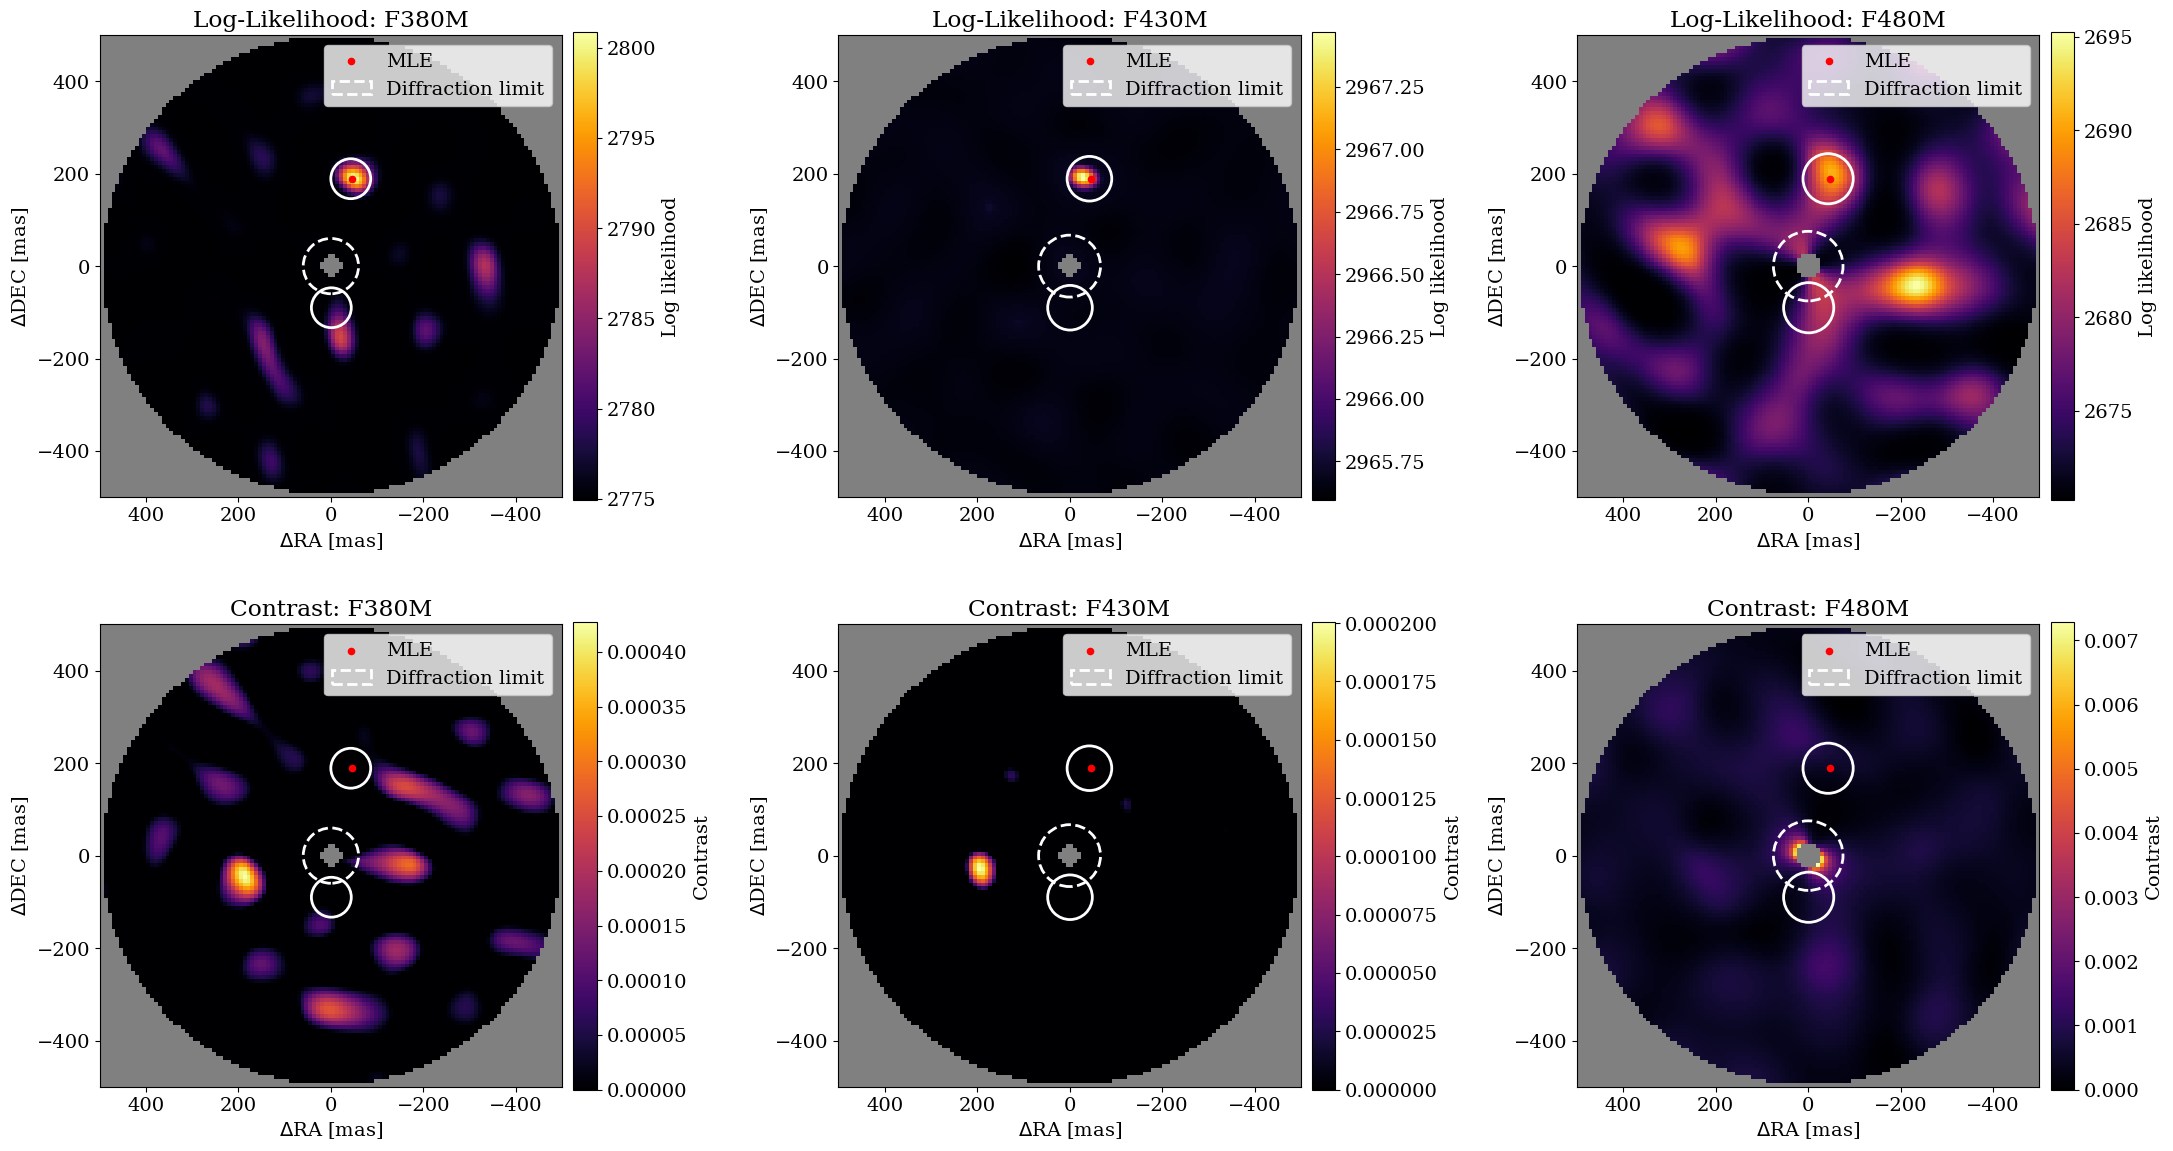

In [9]:

plt.figure(figsize=(22, 12))
for i, filt in enumerate(loglike_ims.keys()):
    loglike_im = loglike_ims[filt]
    contrast_im = contrast_ims[filt]
    oi_data = cal_vis_outputs[filt]
    min_fov, max_fov = fovs[filt]
    wavel = oi_data["wavel"]

    diff_lim = 1e3 * dlu.rad2arcsec(wavel / optics.diameter)

    def add_to_ax(ax):
        ax.scatter(ra_mle, dec_mle, s=80, c="r", marker=".", label="MLE")
        [ax.add_patch(make_circle(binary, 2*min_fov)) for binary in binaries]
        ax.add_patch(make_circle((0, 0), diff_lim, ls="--", label="Diffraction limit"))
        ax.legend()

    #
    ax1 = plt.subplot(2, 3, i + 1)
    plt.imshow(loglike_im, cmap=inferno, aspect="equal", extent=extent)
    plt.colorbar(shrink=0.95, label="Log likelihood", pad=0.02)
    ax1.set(
        title=f"Log-Likelihood: {filt}",
        xlabel="$\\Delta$RA [mas]",
        ylabel="$\\Delta$DEC [mas]",
    )
    add_to_ax(ax1)

    ax2 = plt.subplot(2, 3, i + 4)
    plt.imshow(contrast_im, cmap=inferno, aspect="equal", extent=extent, vmin=0)
    plt.colorbar(shrink=0.95, label="Contrast", pad=0.02)
    ax2.set(
        title=f"Contrast: {filt}",
        xlabel="$\\Delta$RA [mas]",
        ylabel="$\\Delta$DEC [mas]",
    )
    add_to_ax(ax2)

plt.tight_layout()
plt.show()

In [10]:
import numpyro as npy
import numpyro.distributions as dist

ra, dec = binaries[0]


def sampling_fn(oi_objs, model_class):

    # Define priors
    r = 75
    dra = npy.sample("Δ RA", dist.Uniform(ra - r, ra + r))
    ddec = npy.sample("Δ Dec", dist.Uniform(dec - r, dec + r))

    # Track the outputs of the model and the PA/Sep/DMag
    _ = npy.deterministic("PA", dlu.rad2deg(np.arctan2(dec, dra)))
    _ = npy.deterministic("Sep", np.hypot(dra, ddec))

    pred, data, errors = [], [], []
    for filt, oi_data_obj in oi_objs.items():
        log_flux = npy.sample(f"log Flux {filt}", dist.Uniform(-5, -2))
        _ = npy.deterministic(f"Δ Mag {filt}", -2.5 * log_flux)

        cvis_pred = oi_data_obj.model(model_class(dra, ddec, 10**log_flux))
        pred_data = npy.deterministic(f"pred {filt}", cvis_pred)
        pred.append(pred_data)

        # Error scales
        ones = np.ones(pred_data.size // 2)
        vis_jitter = ones * npy.sample(f"vis_jitter {filt}", dist.Uniform(-1.0, 2.0))
        phi_jitter = ones * npy.sample(f"phi_jitter {filt}", dist.Uniform(-1.0, 2.0))
        jitter = 10 ** np.concatenate([vis_jitter, phi_jitter])

        # Get and jitter the data
        cvis, d_cvis = oi_data_obj.flatten_data()
        data.append(cvis)
        errors.append(d_cvis * jitter)

    #
    data = np.concatenate(data)
    errors = np.concatenate(errors)
    pred_data = np.concatenate(pred)
    model_sampler = dist.Normal(pred_data, errors)
    return npy.sample("Sampler", model_sampler, obs=data)

In [11]:
from drpangloss.models import BinaryModelCartesian

oi_data_objs = {}
for i, (filt, oi_data) in enumerate(cal_vis_outputs.items()):
    oi_data_objs[filt] = AmigoOIData(oi_data)

sampler = npy.infer.MCMC(
    npy.infer.NUTS(sampling_fn),
    num_warmup=10000,
    num_samples=10000,
)
sampler.run(jr.PRNGKey(0), oi_data_objs, BinaryModelCartesian)

sample: 100%|█████| 20000/20000 [02:41<00:00, 123.98it/s, 15 steps of size 2.71e-01. acc. prob=0.83]


In [12]:
sampler.print_summary()


                        mean       std    median      5.0%     95.0%     n_eff     r_hat
    log Flux F380M     -3.38      0.13     -3.36     -3.56     -3.19   3423.25      1.00
    log Flux F430M     -4.05      0.43     -3.96     -4.81     -3.45   3902.31      1.00
    log Flux F480M     -2.99      0.07     -2.99     -3.10     -2.88   9027.22      1.00
  phi_jitter F380M      0.20      0.02      0.20      0.17      0.22  10437.78      1.00
  phi_jitter F430M      0.01      0.02      0.01     -0.01      0.04  10819.69      1.00
  phi_jitter F480M     -0.21      0.02     -0.21     -0.24     -0.19  11977.05      1.00
  vis_jitter F380M      0.26      0.02      0.26      0.23      0.29  10747.46      1.00
  vis_jitter F430M      0.07      0.02      0.07      0.04      0.10  11249.12      1.00
  vis_jitter F480M      0.04      0.02      0.04      0.01      0.06  11156.34      1.00
             Δ Dec    193.46      5.96    193.44    183.56    203.03   8988.89      1.00
              Δ RA  

In [13]:
n_bins = 35
to_amp = lambda x: 100 * (np.exp(x) - 1)
to_phase = lambda x: dlu.rad2deg(x)

vis_analysis = {}
for i, (filt, oi_data_obj) in enumerate(oi_data_objs.items()):

    # Get the MCMC error term
    vis_jitter = 10 ** sampler.get_samples()[f"vis_jitter {filt}"].mean()
    phi_jitter = 10 ** sampler.get_samples()[f"phi_jitter {filt}"].mean()

    # Get the MCMC sample predictions
    posterior_pred = sampler.get_samples()[f"pred {filt}"]
    posterior_mean = np.mean(posterior_pred, axis=0)
    posterior_std = np.std(posterior_pred, axis=0)
    n = len(oi_data_obj.vis)

    vis_analysis[filt] = {
        "vis_pred": to_amp(posterior_mean[:n]),
        "vis_std": to_amp(posterior_std[:n]),
        "vis": to_amp(oi_data_obj.vis),
        "d_vis": to_amp(oi_data_obj.d_vis),
        "phi_pred": to_phase(posterior_mean[n:]),
        "phi_std": to_phase(posterior_std[n:]),
        "phi": to_phase(oi_data_obj.phi),
        "d_phi": to_phase(oi_data_obj.d_phi),
        "vis_jitter": vis_jitter,
        "phi_jitter": phi_jitter,
    }

In [14]:
def weighted_average(values, errors):
    var = errors**2
    weights = 1 / var
    average = np.sum(weights * values) / np.sum(weights)
    uncertainty = np.sqrt(np.sum(np.square(weights * errors))) / np.sum(weights)
    return average, uncertainty


def bin_data(x, y, bin_inds):
    return np.array([weighted_average(x[inds], y[inds]) for inds in bin_inds]).T


def chi2(x, pred, std, ddof):
    res = x - pred
    z_score = res / std
    chi2 = np.nansum(z_score**2) / ddof
    return chi2

RMS residual / median data error
F380M:
  Vis: 0.97 - 0.26 - 0.27
  Phi: 0.98 - 0.12 - 0.12
F430M:
  Vis: 0.97 - 0.30 - 0.31
  Phi: 0.97 - 0.14 - 0.14
F480M:
  Vis: 0.94 - 0.52 - 0.55
  Phi: 0.95 - 0.15 - 0.16


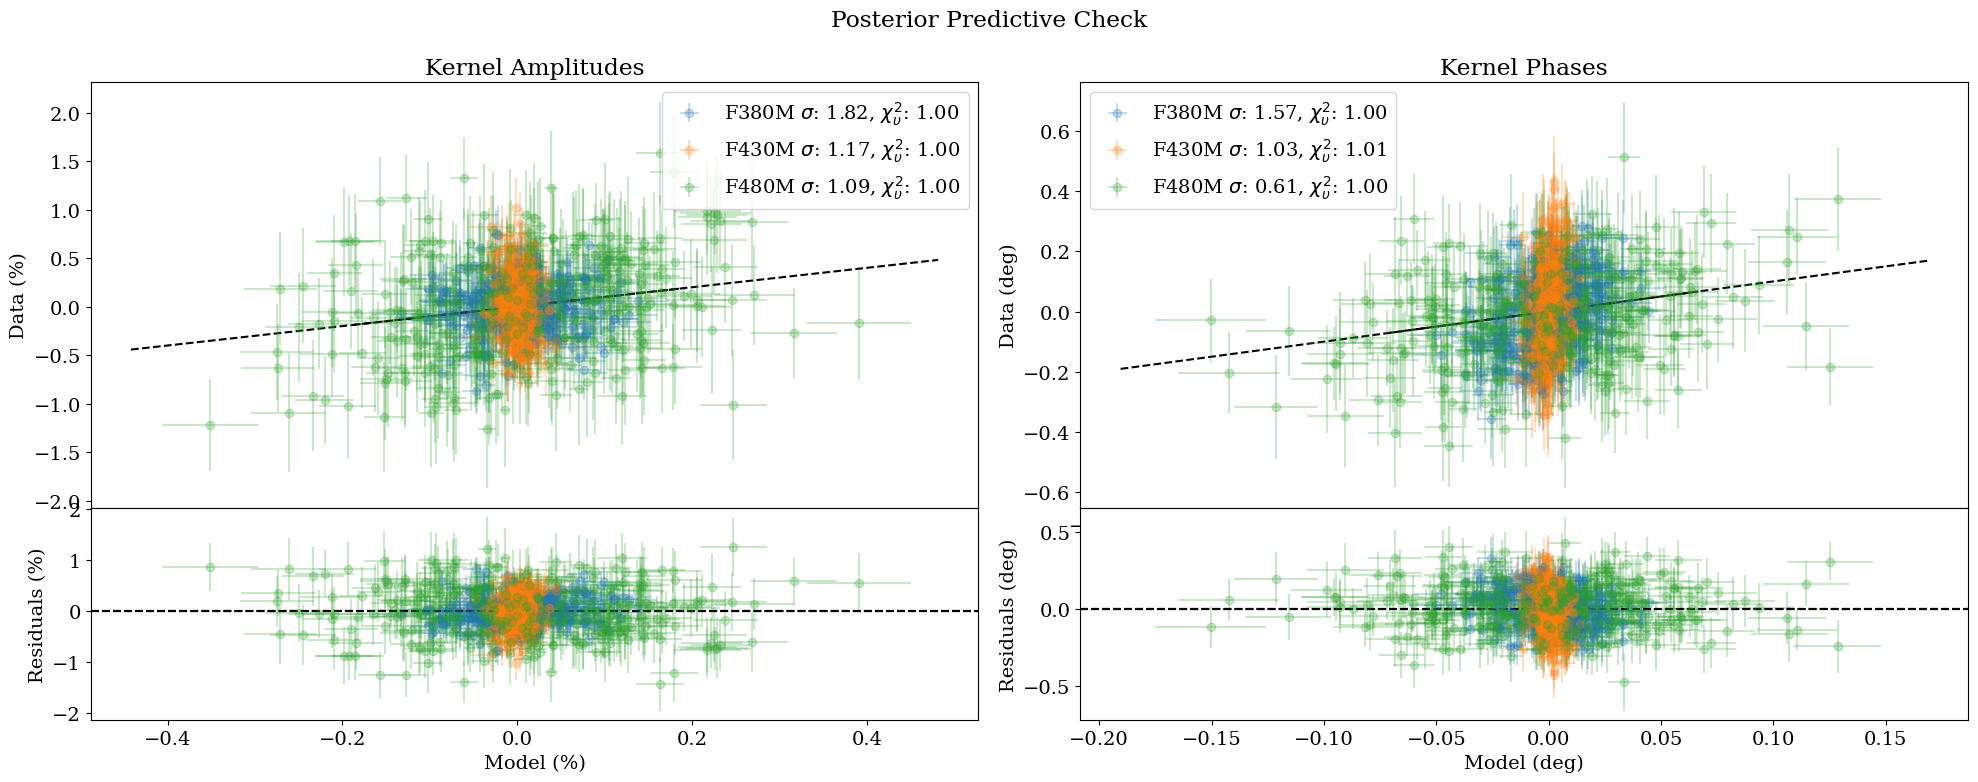

In [15]:
from matplotlib.gridspec import GridSpec

# Create a 2x2 grid with shared x-axes in columns
fig = plt.figure(figsize=(20, 8))
fig.suptitle("Posterior Predictive Check")

gs = GridSpec(2, 2, height_ratios=[2, 1], hspace=0.0)  # less vertical spacing

# Main plots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Residual plots
res1 = fig.add_subplot(gs[1, 0], sharex=ax1)
res2 = fig.add_subplot(gs[1, 1], sharex=ax2)

print("RMS residual / median data error")

for i, filt in enumerate(vis_analysis.keys()):

    vis_pred = vis_analysis[filt]["vis_pred"]
    vis_std = vis_analysis[filt]["vis_std"]
    vis = vis_analysis[filt]["vis"]
    d_vis = vis_analysis[filt]["d_vis"]
    phi_pred = vis_analysis[filt]["phi_pred"]
    phi_std = vis_analysis[filt]["phi_std"]
    phi = vis_analysis[filt]["phi"]
    d_phi = vis_analysis[filt]["d_phi"]
    vis_jitter = vis_analysis[filt]["vis_jitter"]
    phi_jitter = vis_analysis[filt]["phi_jitter"]

    d_vis *= vis_jitter
    d_phi *= phi_jitter

    # Reduce Chi squared
    ddof = len(d_vis) - 3
    vis_chi2 = chi2(vis, vis_pred, d_vis, ddof)
    phi_chi2 = chi2(phi, phi_pred, d_phi, ddof)

    # RMS and Median Error
    rms = lambda x: np.sqrt(np.mean(x**2))
    med_err = lambda x: np.median(np.abs(x))
    vis_precision = rms(vis_pred - vis) / med_err(d_vis)
    phi_precision = rms(phi_pred - phi) / med_err(d_phi)
    print(f"{filt}:")
    print(f"  Vis: {vis_precision:.2f} - {rms(vis_pred - vis):.2f} - {med_err(d_vis):.2f}")
    print(f"  Phi: {phi_precision:.2f} - {rms(phi_pred - phi):.2f} - {med_err(d_phi):.2f}")

    # y = x plotting lines
    vis_med = np.nanmedian(vis_std)
    vis_min, vis_max = np.nanmin(vis_pred), np.nanmax(vis_pred)
    vis_121 = np.linspace(vis_min - 5 * vis_med, vis_max + 5 * vis_med, 100)

    phi_med = np.nanmedian(phi_std)
    phi_min, phi_max = np.nanmin(phi_pred), np.nanmax(phi_pred)
    phi_121 = np.linspace(phi_min - 5 * phi_med, phi_max + 5 * phi_med, 100)

    errplt = lambda ax, *args, **kwargs: ax.errorbar(
        *args, fmt="o", alpha=0.25, color=f"C{i}", **kwargs
    )

    ax1.plot(vis_121, vis_121, "k--")
    errplt(ax1, vis_pred, vis, yerr=d_vis, xerr=vis_std)
    errplt(res1, vis_pred, vis_pred - vis, yerr=d_vis, xerr=vis_std)
    errplt(ax1, [], [], xerr=[], yerr=[], label=rf"{filt} $\sigma$: {vis_jitter:.2f}, $\chi^2_\upsilon$: {vis_chi2:.2f}")

    ax2.plot(phi_121, phi_121, "k--")
    errplt(ax2, phi_pred, phi, yerr=d_phi, xerr=phi_std)
    errplt(res2, phi_pred, phi_pred - phi, yerr=d_phi, xerr=phi_std)
    errplt(ax2, [], [], xerr=[], yerr=[], label=rf"{filt} $\sigma$: {phi_jitter:.2f}, $\chi^2_\upsilon$: {phi_chi2:.2f}")

    ax1.set(title="Kernel Amplitudes", ylabel="Data (%)", xlabel="Model (%)")
    ax2.set(title="Kernel Phases",  ylabel="Data (deg)", xlabel="Model (deg)")

    res1.set(ylabel="Residuals (%)", xlabel="Model (%)")
    res2.set(ylabel="Residuals (deg)", xlabel="Model (deg)")
    ax1.legend()
    ax2.legend()

    res1.axhline(0, color="k", ls="--")
    res2.axhline(0, color="k", ls="--")

plt.tight_layout()
plt.show()

RMS residual / median data error
F380M:
  Vis: 1.21 - 0.10 - 0.09
  Phi: 1.12 - 0.04 - 0.04
F430M:
  Vis: 0.94 - 0.09 - 0.10
  Phi: 1.40 - 0.06 - 0.04
F480M:
  Vis: 1.08 - 0.18 - 0.17
  Phi: 1.00 - 0.05 - 0.05


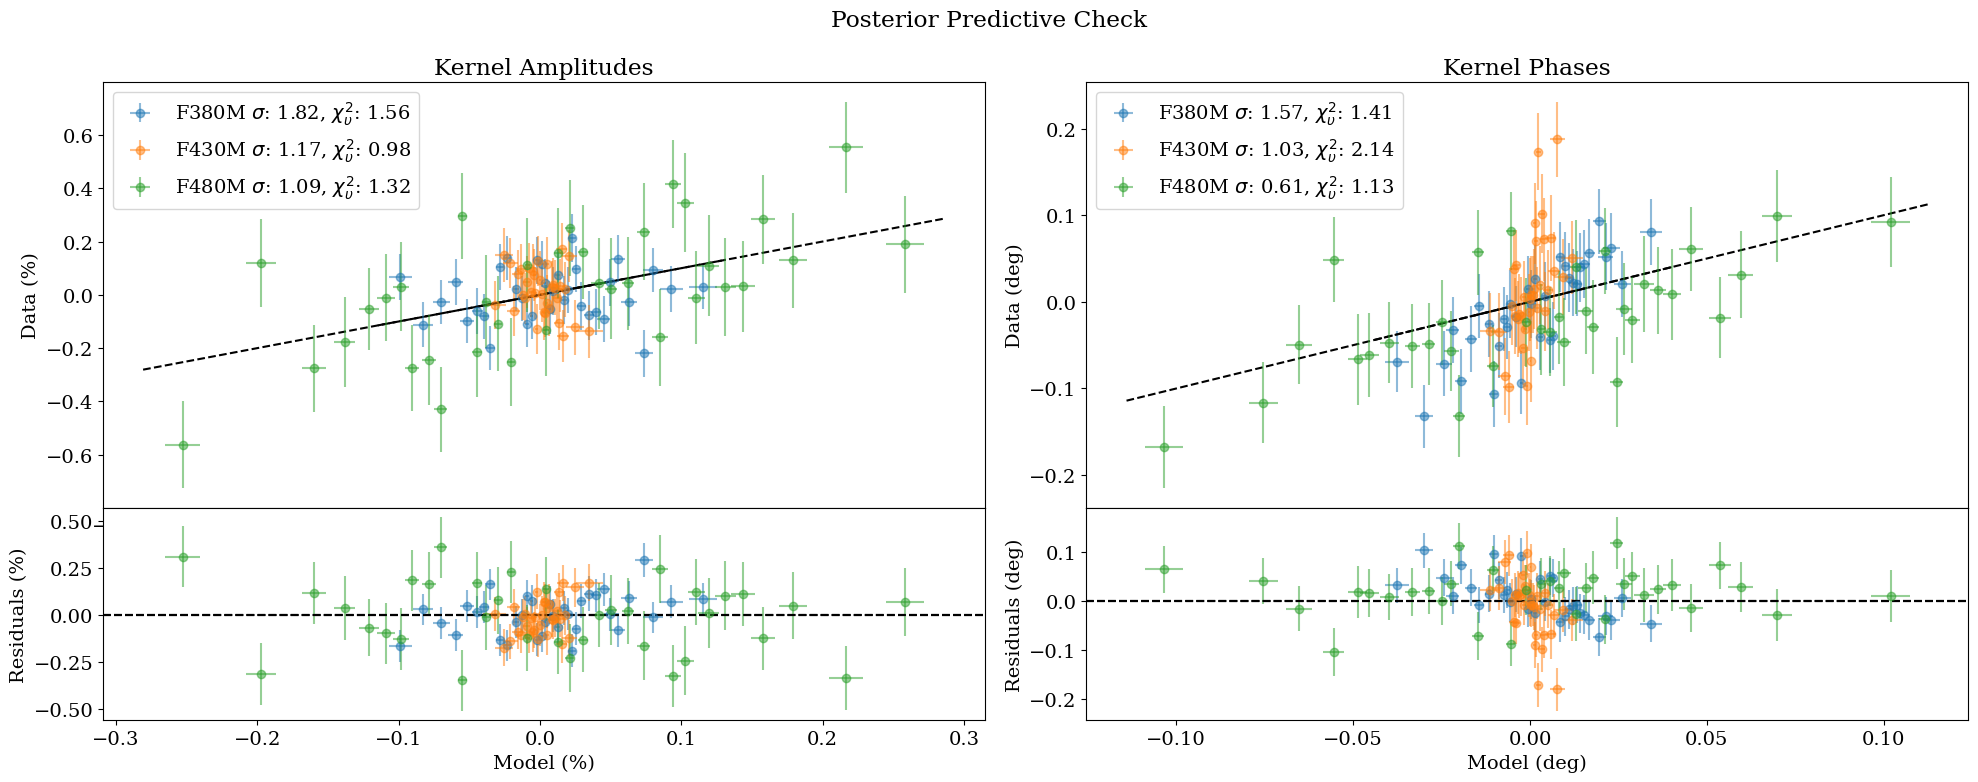

In [16]:
from matplotlib.gridspec import GridSpec

# Create a 2x2 grid with shared x-axes in columns
fig = plt.figure(figsize=(20, 8))
fig.suptitle("Posterior Predictive Check")

gs = GridSpec(2, 2, height_ratios=[2, 1], hspace=0.0)  # less vertical spacing

# Main plots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Residual plots
res1 = fig.add_subplot(gs[1, 0], sharex=ax1)
res2 = fig.add_subplot(gs[1, 1], sharex=ax2)

print("RMS residual / median data error")

for i, filt in enumerate(vis_analysis.keys()):

    vis_pred = vis_analysis[filt]["vis_pred"]
    vis_std = vis_analysis[filt]["vis_std"]
    vis = vis_analysis[filt]["vis"]
    d_vis = vis_analysis[filt]["d_vis"]
    phi_pred = vis_analysis[filt]["phi_pred"]
    phi_std = vis_analysis[filt]["phi_std"]
    phi = vis_analysis[filt]["phi"]
    d_phi = vis_analysis[filt]["d_phi"]
    vis_jitter = vis_analysis[filt]["vis_jitter"]
    phi_jitter = vis_analysis[filt]["phi_jitter"]

    d_vis *= vis_jitter
    d_phi *= phi_jitter

    # Bin the visibilities
    bin_inds = np.array_split(np.argsort(vis_pred), n_bins)
    vis_pred, vis_std = bin_data(vis_pred, vis_std, bin_inds)
    vis, d_vis = bin_data(vis, d_vis, bin_inds)

    # Bin the phases
    bin_inds = np.array_split(np.argsort(phi_pred), n_bins)
    phi_pred, phi_std = bin_data(phi_pred, phi_std, bin_inds)
    phi, d_phi = bin_data(phi, d_phi, bin_inds)

    # Reduce Chi squared
    ddof = len(d_vis) - 3
    vis_chi2 = chi2(vis, vis_pred, d_vis, ddof)
    phi_chi2 = chi2(phi, phi_pred, d_phi, ddof)

    # RMS and Median Error
    rms = lambda x: np.sqrt(np.mean(x**2))
    med_err = lambda x: np.median(np.abs(x))
    vis_precision = rms(vis_pred - vis) / med_err(d_vis)
    phi_precision = rms(phi_pred - phi) / med_err(d_phi)
    print(f"{filt}:")
    print(f"  Vis: {vis_precision:.2f} - {rms(vis_pred - vis):.2f} - {med_err(d_vis):.2f}")
    print(f"  Phi: {phi_precision:.2f} - {rms(phi_pred - phi):.2f} - {med_err(d_phi):.2f}")

    # y = x plotting lines
    vis_med = np.nanmedian(vis_std)
    vis_min, vis_max = np.nanmin(vis_pred), np.nanmax(vis_pred)
    vis_121 = np.linspace(vis_min - 5 * vis_med, vis_max + 5 * vis_med, 100)

    phi_med = np.nanmedian(phi_std)
    phi_min, phi_max = np.nanmin(phi_pred), np.nanmax(phi_pred)
    phi_121 = np.linspace(phi_min - 5 * phi_med, phi_max + 5 * phi_med, 100)

    errplt = lambda ax, *args, **kwargs: ax.errorbar(
        *args, fmt="o", alpha=0.5, color=f"C{i}", **kwargs
    )

    ax1.plot(vis_121, vis_121, "k--")
    errplt(ax1, vis_pred, vis, yerr=d_vis, xerr=vis_std)
    errplt(res1, vis_pred, vis_pred - vis, yerr=d_vis, xerr=vis_std)
    errplt(ax1, [], [], xerr=[], yerr=[], label=rf"{filt} $\sigma$: {vis_jitter:.2f}, $\chi^2_\upsilon$: {vis_chi2:.2f}")

    ax2.plot(phi_121, phi_121, "k--")
    errplt(ax2, phi_pred, phi, yerr=d_phi, xerr=phi_std)
    errplt(res2, phi_pred, phi_pred - phi, yerr=d_phi, xerr=phi_std)
    errplt(ax2, [], [], xerr=[], yerr=[], label=rf"{filt} $\sigma$: {phi_jitter:.2f}, $\chi^2_\upsilon$: {phi_chi2:.2f}")

    ax1.set(title="Kernel Amplitudes", ylabel="Data (%)", xlabel="Model (%)")
    ax2.set(title="Kernel Phases",  ylabel="Data (deg)", xlabel="Model (deg)")

    res1.set(ylabel="Residuals (%)", xlabel="Model (%)")
    res2.set(ylabel="Residuals (deg)", xlabel="Model (deg)")
    ax1.legend()
    ax2.legend()

    res1.axhline(0, color="k", ls="--")
    res2.axhline(0, color="k", ls="--")

plt.tight_layout()
plt.show()

RMS residual, median data error
F380M:
  Vis: 0.10, 0.09
  Phi: 0.04, 0.04
F430M:
  Vis: 0.09, 0.10
  Phi: 0.06, 0.04
F480M:
  Vis: 0.18, 0.17
  Phi: 0.05, 0.05


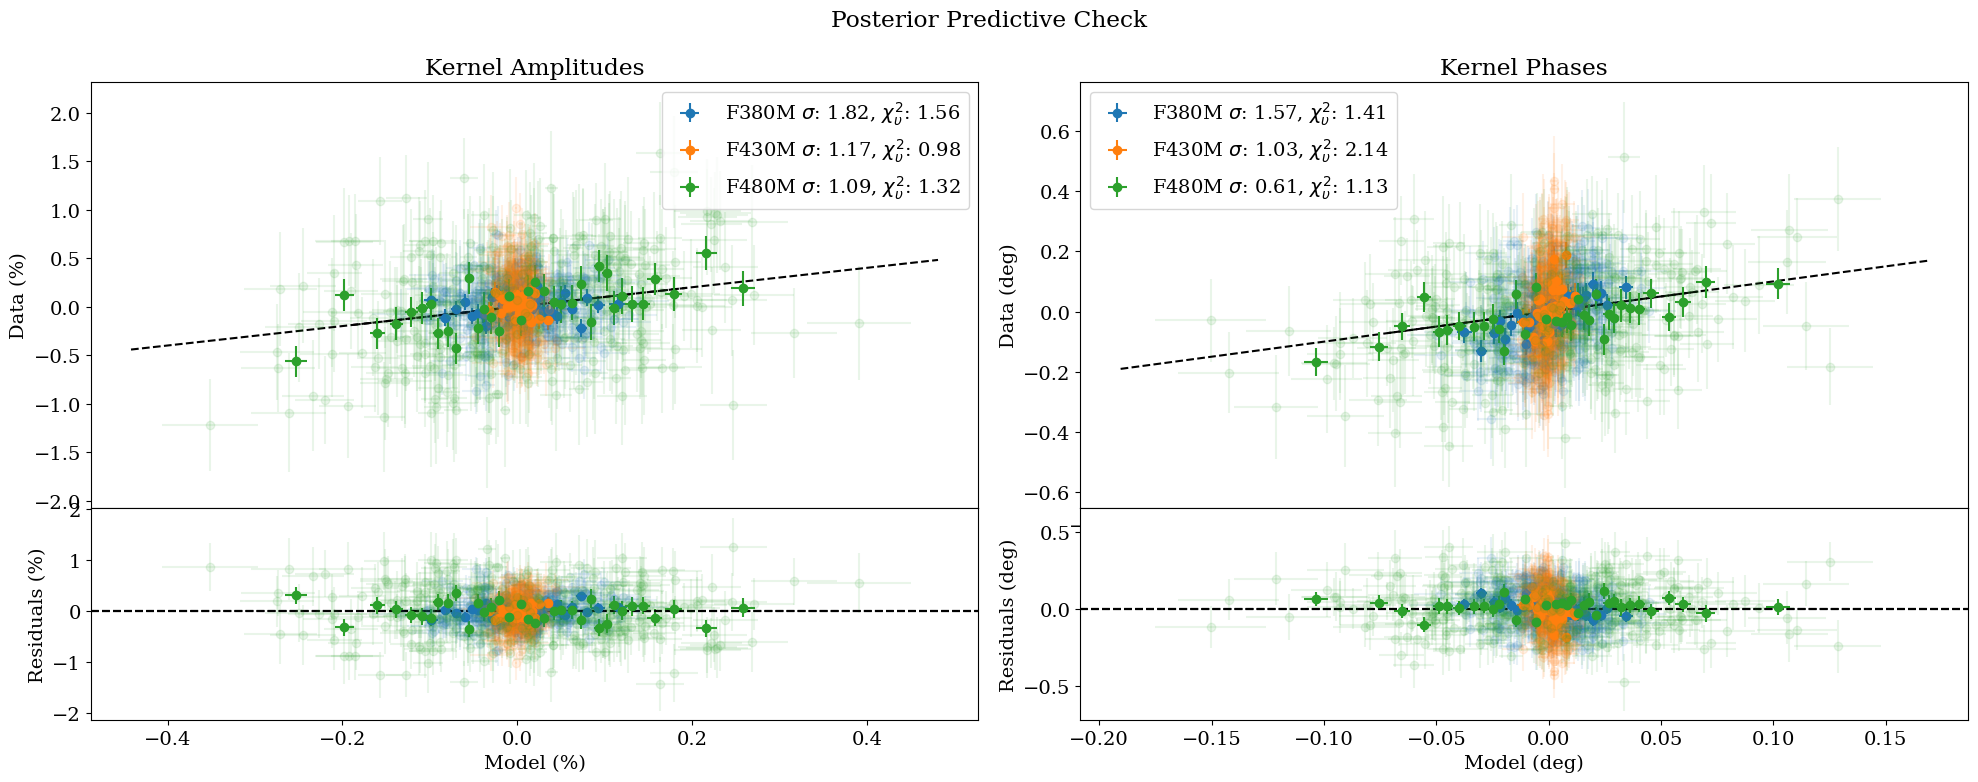

In [17]:
from matplotlib.gridspec import GridSpec

# Create a 2x2 grid with shared x-axes in columns
fig = plt.figure(figsize=(20, 8))
fig.suptitle("Posterior Predictive Check")

gs = GridSpec(2, 2, height_ratios=[2, 1], hspace=0.0)  # less vertical spacing

# Main plots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Residual plots
res1 = fig.add_subplot(gs[1, 0], sharex=ax1)
res2 = fig.add_subplot(gs[1, 1], sharex=ax2)

print("RMS residual, median data error")

for i, filt in enumerate(vis_analysis.keys()):

    vis_pred = vis_analysis[filt]["vis_pred"]
    vis_std = vis_analysis[filt]["vis_std"]
    vis = vis_analysis[filt]["vis"]
    d_vis = vis_analysis[filt]["d_vis"]
    phi_pred = vis_analysis[filt]["phi_pred"]
    phi_std = vis_analysis[filt]["phi_std"]
    phi = vis_analysis[filt]["phi"]
    d_phi = vis_analysis[filt]["d_phi"]
    vis_jitter = vis_analysis[filt]["vis_jitter"]
    phi_jitter = vis_analysis[filt]["phi_jitter"]

    d_vis *= vis_jitter
    d_phi *= phi_jitter

    errplt = lambda ax, *args, **kwargs: ax.errorbar(
        *args, fmt="o", color=f"C{i}", **kwargs
    )

    alpha = 0.1
    errplt(ax1, vis_pred, vis, yerr=d_vis, xerr=vis_std, alpha=alpha)
    errplt(ax2, phi_pred, phi, yerr=d_phi, xerr=phi_std, alpha=alpha)
    errplt(res1, vis_pred, vis_pred - vis, yerr=d_vis, xerr=vis_std, alpha=alpha)
    errplt(res2, phi_pred, phi_pred - phi, yerr=d_phi, xerr=phi_std, alpha=alpha)

    # y = x plotting lines
    vis_med = np.nanmedian(vis_std)
    vis_min, vis_max = np.nanmin(vis_pred), np.nanmax(vis_pred)
    vis_121 = np.linspace(vis_min - 5 * vis_med, vis_max + 5 * vis_med, 100)
    ax1.plot(vis_121, vis_121, "k--")

    phi_med = np.nanmedian(phi_std)
    phi_min, phi_max = np.nanmin(phi_pred), np.nanmax(phi_pred)
    phi_121 = np.linspace(phi_min - 5 * phi_med, phi_max + 5 * phi_med, 100)
    ax2.plot(phi_121, phi_121, "k--")

    # Bin the visibilities
    bin_inds = np.array_split(np.argsort(vis_pred), n_bins)
    vis_pred, vis_std = bin_data(vis_pred, vis_std, bin_inds)
    vis, d_vis = bin_data(vis, d_vis, bin_inds)

    # Bin the phases
    bin_inds = np.array_split(np.argsort(phi_pred), n_bins)
    phi_pred, phi_std = bin_data(phi_pred, phi_std, bin_inds)
    phi, d_phi = bin_data(phi, d_phi, bin_inds)

    # Reduce Chi squared
    ddof = len(d_vis) - 3
    vis_chi2 = chi2(vis, vis_pred, d_vis, ddof)
    phi_chi2 = chi2(phi, phi_pred, d_phi, ddof)

    # RMS and Median Error
    rms = lambda x: np.sqrt(np.mean(x**2))
    med_err = lambda x: np.median(np.abs(x))
    print(f"{filt}:")
    print(f"  Vis: {rms(vis_pred - vis):.2f}, {med_err(d_vis):.2f}")
    print(f"  Phi: {rms(phi_pred - phi):.2f}, {med_err(d_phi):.2f}")

    alpha = 1.
    errplt(ax1, vis_pred, vis, yerr=d_vis, xerr=vis_std, alpha=alpha)
    errplt(res1, vis_pred, vis_pred - vis, yerr=d_vis, xerr=vis_std, alpha=alpha)
    errplt(ax1, [], [], xerr=[], yerr=[], label=rf"{filt} $\sigma$: {vis_jitter:.2f}, $\chi^2_\upsilon$: {vis_chi2:.2f}")

    errplt(ax2, phi_pred, phi, yerr=d_phi, xerr=phi_std, alpha=alpha)
    errplt(res2, phi_pred, phi_pred - phi, yerr=d_phi, xerr=phi_std, alpha=alpha)
    errplt(ax2, [], [], xerr=[], yerr=[], label=rf"{filt} $\sigma$: {phi_jitter:.2f}, $\chi^2_\upsilon$: {phi_chi2:.2f}", alpha=alpha)

    ax1.set(title="Kernel Amplitudes", ylabel="Data (%)", xlabel="Model (%)")
    ax2.set(title="Kernel Phases",  ylabel="Data (deg)", xlabel="Model (deg)")

    res1.set(ylabel="Residuals (%)", xlabel="Model (%)")
    res2.set(ylabel="Residuals (deg)", xlabel="Model (deg)")
    ax1.legend()
    ax2.legend()

    res1.axhline(0, color="k", ls="--")
    res2.axhline(0, color="k", ls="--")

plt.tight_layout()
plt.show()

Parameter log Flux in chain F430M is not constrained


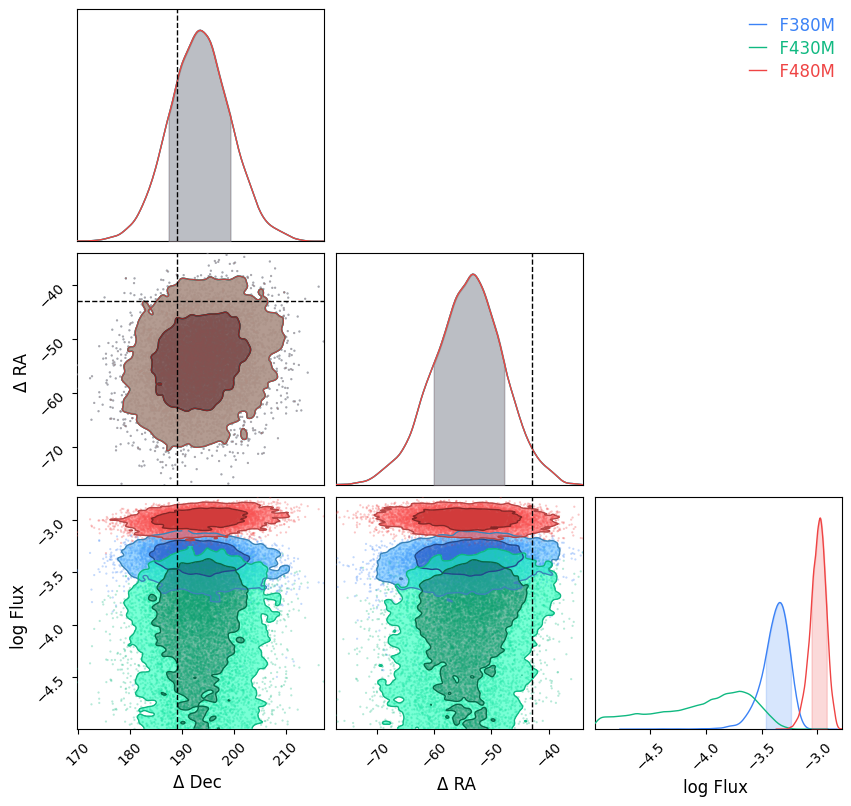

In [18]:
from chainconsumer import ChainConsumer, Chain, Truth
import pandas as pd

true_ra, true_dec = binaries[0]
truths = {
    "Δ Dec": true_dec,
    "Δ RA": true_ra,
    "log Flux": -1.78,
}

c = ChainConsumer()
c.add_truth(Truth(location=truths))

for filt in vis_analysis.keys():
    params = ["Δ Dec", "Δ RA", f"log Flux {filt}"]
    keys = ["Δ Dec", "Δ RA", "log Flux"]

    results = sampler.get_samples()
    results = {key: results[param] for key, param in zip(keys, params)}
    cc_df = pd.DataFrame.from_dict(results)

    c.add_chain(
        Chain(
            samples=cc_df,
            name=filt,
            plot_cloud=True,
            marker_style="*",
            marker_size=100,
        )
    )

c.plotter.plot()
plt.show()

Parameter log Flux F430M in chain F480M is not constrained


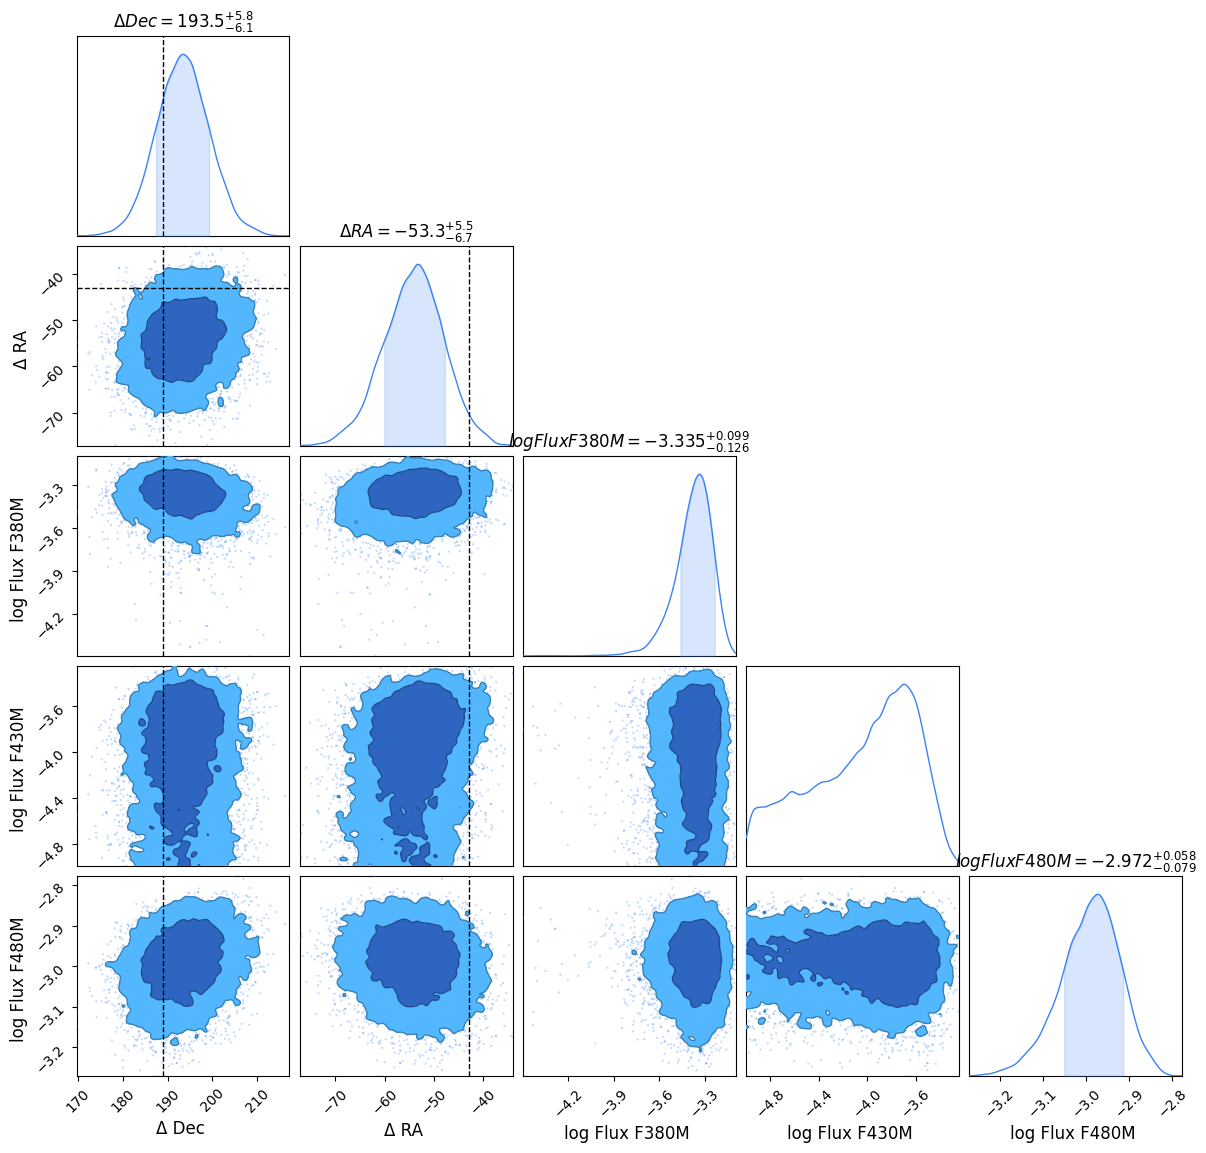

In [19]:
from chainconsumer import ChainConsumer, Chain, Truth
import pandas as pd

true_ra, true_dec = binaries[0]
truths = {
    "Δ Dec": true_dec,
    "Δ RA": true_ra,
    "log Flux F380M": -1.78,
    "log Flux F430M": -1.78,
    "log Flux F480M": -1.78,
}

c = ChainConsumer()
c.add_truth(Truth(location=truths))
results = sampler.get_samples()

keys = ["Δ Dec", "Δ RA"]
for filt in vis_analysis.keys():
    keys.append(f"log Flux {filt}")

results = {key: results[key] for key in keys}
cc_df = pd.DataFrame.from_dict(results)

c.add_chain(
    Chain(
        samples=cc_df,
        name=filt,
        plot_cloud=True,
        marker_style="*",
        marker_size=100,
    )
)

c.plotter.plot()
plt.show()

In [20]:
import numpyro as npy
import numpyro.distributions as dist

ra, dec = binaries[0]
# ra, dec = binaries[1]

def sampling_fn(oi_data_obj, model_class):

    # Define priors
    r = 75
    dra = npy.sample("Δ RA", dist.Uniform(ra - r, ra + r))
    ddec = npy.sample("Δ Dec", dist.Uniform(dec - r, dec + r))
    log_flux = npy.sample("log Flux", dist.Uniform(-5, -2))
    vis_jitter = npy.sample("vis_jitter", dist.Uniform(-1.0, 2.0))
    phi_jitter = npy.sample("phi_jitter", dist.Uniform(-1.0, 2.0))

    # Error scales
    ones = np.ones(oi_data_obj.vis.size)
    err_scale = 10 ** np.concatenate([ones * vis_jitter, ones * phi_jitter])

    # Track the outputs of the model and the PA/Sep/DMag
    _ = npy.deterministic("PA", dlu.rad2deg(np.arctan2(dec, dra)))
    _ = npy.deterministic("Sep", np.hypot(dra, ddec))
    _ = npy.deterministic("Δ Mag", -2.5 * log_flux)
    pred_data = npy.deterministic(
        "pred", oi_data_obj.model(model_class(dra, ddec, 10**log_flux))
    )

    data, errors = oi_data_obj.flatten_data()
    model_sampler = dist.Normal(pred_data, errors * err_scale)
    return npy.sample("Sampler", model_sampler, obs=data)

In [ ]:
from drpangloss.models import OIData, BinaryModelCartesian
# from amigo.vis_analysis import AmigoOIData

samplers, oi_objs = {}, {}

for i, (filt, oi_data) in enumerate(cal_vis_outputs.items()):
    oi_data_obj = AmigoOIData(oi_data)
    oi_data_obj = oi_data_obj.multiply("d_vis", 1)
    oi_data_obj = oi_data_obj.multiply("d_phi", 1)

    sampler = npy.infer.MCMC(
        npy.infer.NUTS(sampling_fn),
        num_warmup=10000,
        num_samples=10000,
    )
    sampler.run(jr.PRNGKey(0), oi_data_obj, BinaryModelCartesian)

    posterior_pred = sampler.get_samples()["pred"]
    vis_jitter = 10 ** sampler.get_samples()["vis_jitter"].mean()
    phi_jitter = 10 ** sampler.get_samples()["phi_jitter"].mean()
    print(f"{filt} Error scales: {vis_jitter:.2f}, {phi_jitter:.2f}")
    print()

    samplers[filt] = sampler
    oi_objs[filt] = oi_data_obj

sample: 100%|██████| 20000/20000 [00:44<00:00, 444.95it/s, 7 steps of size 5.34e-01. acc. prob=0.92]


F380M Error scales: 1.81, 1.57



sample: 100%|█████| 20000/20000 [01:14<00:00, 269.17it/s, 15 steps of size 2.18e-01. acc. prob=0.90]


F430M Error scales: 1.17, 1.04



  0%|                                                                     | 0/20000 [00:00<?, ?it/s]

In [21]:
sampler.get_samples().keys()

In [22]:
print(sampler.get_samples().keys())

for sampler in samplers.values():
    sampler.print_summary()

In [23]:
sampler.get_samples().keys()

In [24]:
def weighted_average(values, errors):
    var = errors**2
    weights = 1 / var
    average = np.sum(weights * values) / np.sum(weights)
    uncertainty = np.sqrt(np.sum(np.square(weights * errors))) / np.sum(weights)
    return average, uncertainty


def bin_data(x, y, bin_inds):
    return np.array([weighted_average(x[inds], y[inds]) for inds in bin_inds]).T


def chi2(x, pred, std, ddof):
    res = x - pred
    z_score = res / std
    chi2 = np.nansum(z_score**2) / ddof
    return chi2

In [25]:
n_bins = 35
to_amp = lambda x: 100 * (np.exp(x) - 1)
to_phase = lambda x: dlu.rad2deg(x)

vis_analysis = {}
for i, (filt, oi_data_obj) in enumerate(oi_objs.items()):

    sampler = samplers[filt]

    # Get the MCMC error term
    vis_jitter = 10 ** sampler.get_samples()["vis_jitter"].mean()
    phi_jitter = 10 ** sampler.get_samples()["phi_jitter"].mean()

    # Get the MCMC sample predictions
    posterior_pred = sampler.get_samples()["pred"]
    posterior_mean = np.mean(posterior_pred, axis=0)
    posterior_std = np.std(posterior_pred, axis=0)
    n = len(oi_data_obj.vis)

    vis_analysis[filt] = {
        "vis_pred": to_amp(posterior_mean[:n]),
        "vis_std": to_amp(posterior_std[:n]),
        "vis": to_amp(oi_data_obj.vis),
        "d_vis": to_amp(oi_data_obj.d_vis),
        "phi_pred": to_phase(posterior_mean[n:]),
        "phi_std": to_phase(posterior_std[n:]),
        "phi": to_phase(oi_data_obj.phi),
        "d_phi": to_phase(oi_data_obj.d_phi),
        "vis_jitter": vis_jitter,
        "phi_jitter": phi_jitter,
    }

In [26]:
from matplotlib.gridspec import GridSpec

# Create a 2x2 grid with shared x-axes in columns
fig = plt.figure(figsize=(20, 8))
fig.suptitle("Posterior Predictive Check")

gs = GridSpec(2, 2, height_ratios=[2, 1], hspace=0.0)  # less vertical spacing

# Main plots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Residual plots
res1 = fig.add_subplot(gs[1, 0], sharex=ax1)
res2 = fig.add_subplot(gs[1, 1], sharex=ax2)

print("RMS residual / median data error")

for i, (filt, oi_data_obj) in enumerate(oi_objs.items()):

    vis_pred = vis_analysis[filt]["vis_pred"]
    vis_std = vis_analysis[filt]["vis_std"]
    vis = vis_analysis[filt]["vis"]
    d_vis = vis_analysis[filt]["d_vis"]
    phi_pred = vis_analysis[filt]["phi_pred"]
    phi_std = vis_analysis[filt]["phi_std"]
    phi = vis_analysis[filt]["phi"]
    d_phi = vis_analysis[filt]["d_phi"]
    vis_jitter = vis_analysis[filt]["vis_jitter"]
    phi_jitter = vis_analysis[filt]["phi_jitter"]

    # Reduce Chi squared
    ddof = len(d_vis) - 3
    vis_chi2 = chi2(vis, vis_pred, d_vis, ddof)
    phi_chi2 = chi2(phi, phi_pred, d_phi, ddof)

    # RMS and Median Error
    rms = lambda x: np.sqrt(np.mean(x**2))
    med_err = lambda x: np.median(np.abs(x))
    vis_precision = rms(vis_pred - vis) / med_err(d_vis)
    phi_precision = rms(phi_pred - phi) / med_err(d_phi)
    print(f"{filt}:")
    print(f"  Vis: {vis_precision:.2f} - {rms(vis_pred - vis):.2f} - {med_err(d_vis):.2f}")
    print(f"  Phi: {phi_precision:.2f} - {rms(phi_pred - phi):.2f} - {med_err(d_phi):.2f}")

    # y = x plotting lines
    vis_med = np.nanmedian(vis_std)
    vis_min, vis_max = np.nanmin(vis_pred), np.nanmax(vis_pred)
    vis_121 = np.linspace(vis_min - 5 * vis_med, vis_max + 5 * vis_med, 100)

    phi_med = np.nanmedian(phi_std)
    phi_min, phi_max = np.nanmin(phi_pred), np.nanmax(phi_pred)
    phi_121 = np.linspace(phi_min - 5 * phi_med, phi_max + 5 * phi_med, 100)

    errplt = lambda ax, *args, **kwargs: ax.errorbar(
        *args, fmt="o", alpha=0.25, color=f"C{i}", **kwargs
    )

    ax1.plot(vis_121, vis_121, "k--")
    errplt(ax1, vis_pred, vis, yerr=d_vis, xerr=vis_std)
    errplt(res1, vis_pred, vis_pred - vis, yerr=d_vis, xerr=vis_std)
    errplt(ax1, [], [], xerr=[], yerr=[], label=rf"{filt} $\sigma$: {vis_jitter:.2f}, $\chi^2_\upsilon$: {vis_chi2:.2f}")

    ax2.plot(phi_121, phi_121, "k--")
    errplt(ax2, phi_pred, phi, yerr=d_phi, xerr=phi_std)
    errplt(res2, phi_pred, phi_pred - phi, yerr=d_phi, xerr=phi_std)
    errplt(ax2, [], [], xerr=[], yerr=[], label=rf"{filt} $\sigma$: {phi_jitter:.2f}, $\chi^2_\upsilon$: {phi_chi2:.2f}")

    ax1.set(title="Kernel Amplitudes", ylabel="Data (%)", xlabel="Model (%)")
    ax2.set(title="Kernel Phases",  ylabel="Data (deg)", xlabel="Model (deg)")

    res1.set(ylabel="Residuals (%)", xlabel="Model (%)")
    res2.set(ylabel="Residuals (deg)", xlabel="Model (deg)")
    ax1.legend()
    ax2.legend()

    res1.axhline(0, color="k", ls="--")
    res2.axhline(0, color="k", ls="--")

plt.tight_layout()
plt.show()

In [27]:
from matplotlib.gridspec import GridSpec

# Create a 2x2 grid with shared x-axes in columns
fig = plt.figure(figsize=(20, 8))
fig.suptitle("Posterior Predictive Check")

gs = GridSpec(2, 2, height_ratios=[2, 1], hspace=0.0)  # less vertical spacing

# Main plots
ax1 = fig.add_subplot(gs[0, 0])
ax2 = fig.add_subplot(gs[0, 1])

# Residual plots
res1 = fig.add_subplot(gs[1, 0], sharex=ax1)
res2 = fig.add_subplot(gs[1, 1], sharex=ax2)

print("RMS residual / median data error")

for i, (filt, oi_data_obj) in enumerate(oi_objs.items()):

    vis_pred = vis_analysis[filt]["vis_pred"]
    vis_std = vis_analysis[filt]["vis_std"]
    vis = vis_analysis[filt]["vis"]
    d_vis = vis_analysis[filt]["d_vis"]
    phi_pred = vis_analysis[filt]["phi_pred"]
    phi_std = vis_analysis[filt]["phi_std"]
    phi = vis_analysis[filt]["phi"]
    d_phi = vis_analysis[filt]["d_phi"]
    vis_jitter = vis_analysis[filt]["vis_jitter"]
    phi_jitter = vis_analysis[filt]["phi_jitter"]
    
    # Bin the visibilities
    bin_inds = np.array_split(np.argsort(vis_pred), n_bins)
    vis_pred, vis_std = bin_data(vis_pred, vis_std, bin_inds)
    vis, d_vis = bin_data(vis, d_vis, bin_inds)

    # Bin the phases
    bin_inds = np.array_split(np.argsort(phi_pred), n_bins)
    phi_pred, phi_std = bin_data(phi_pred, phi_std, bin_inds)
    phi, d_phi = bin_data(phi, d_phi, bin_inds)

    # Reduce Chi squared
    ddof = len(d_vis) - 3
    vis_chi2 = chi2(vis, vis_pred, d_vis, ddof)
    phi_chi2 = chi2(phi, phi_pred, d_phi, ddof)

    # RMS and Median Error
    rms = lambda x: np.sqrt(np.mean(x**2))
    med_err = lambda x: np.median(np.abs(x))
    vis_precision = rms(vis_pred - vis) / med_err(d_vis)
    phi_precision = rms(phi_pred - phi) / med_err(d_phi)
    print(f"{filt}:")
    print(f"  Vis: {vis_precision:.2f} - {rms(vis_pred - vis):.2f} - {med_err(d_vis):.2f}")
    print(f"  Phi: {phi_precision:.2f} - {rms(phi_pred - phi):.2f} - {med_err(d_phi):.2f}")

    # y = x plotting lines
    vis_med = np.nanmedian(vis_std)
    vis_min, vis_max = np.nanmin(vis_pred), np.nanmax(vis_pred)
    vis_121 = np.linspace(vis_min - 5 * vis_med, vis_max + 5 * vis_med, 100)

    phi_med = np.nanmedian(phi_std)
    phi_min, phi_max = np.nanmin(phi_pred), np.nanmax(phi_pred)
    phi_121 = np.linspace(phi_min - 5 * phi_med, phi_max + 5 * phi_med, 100)

    errplt = lambda ax, *args, **kwargs: ax.errorbar(
        *args, fmt="o", alpha=0.5, color=f"C{i}", **kwargs
    )

    ax1.plot(vis_121, vis_121, "k--")
    errplt(ax1, vis_pred, vis, yerr=d_vis, xerr=vis_std)
    errplt(res1, vis_pred, vis_pred - vis, yerr=d_vis, xerr=vis_std)
    errplt(ax1, [], [], xerr=[], yerr=[], label=rf"{filt} $\sigma$: {vis_jitter:.2f}, $\chi^2_\upsilon$: {vis_chi2:.2f}")

    ax2.plot(phi_121, phi_121, "k--")
    errplt(ax2, phi_pred, phi, yerr=d_phi, xerr=phi_std)
    errplt(res2, phi_pred, phi_pred - phi, yerr=d_phi, xerr=phi_std)
    errplt(ax2, [], [], xerr=[], yerr=[], label=rf"{filt} $\sigma$: {phi_jitter:.2f}, $\chi^2_\upsilon$: {phi_chi2:.2f}")

    ax1.set(title="Kernel Amplitudes", ylabel="Data (%)", xlabel="Model (%)")
    ax2.set(title="Kernel Phases",  ylabel="Data (deg)", xlabel="Model (deg)")

    res1.set(ylabel="Residuals (%)", xlabel="Model (%)")
    res2.set(ylabel="Residuals (deg)", xlabel="Model (deg)")
    ax1.legend()
    ax2.legend()

    res1.axhline(0, color="k", ls="--")
    res2.axhline(0, color="k", ls="--")

plt.tight_layout()
plt.show()

In [28]:
from chainconsumer import ChainConsumer, Chain, Truth
import pandas as pd

true_ra, true_dec = binaries[0]
truths = {
    "Δ Dec": true_dec,
    "Δ RA": true_ra,
    # "log Flux": -1.78,
}

c = ChainConsumer()
c.add_truth(Truth(location=truths))

for filt, sampler in samplers.items():
    # if filt== "F430M":
    #     continue
    results = sampler.get_samples()
    results = {key: results[key] for key in ["Δ Dec", "Δ RA", "log Flux"]}
    cc_df = pd.DataFrame.from_dict(results)

    c.add_chain(
        Chain(
            samples=cc_df,
            name=filt,
            plot_cloud=True,
            marker_style="*",
            marker_size=100,
        )
    )

c.plotter.plot()
plt.show()

In [29]:
true_ra, true_dec = binaries[0]
truths = {
    "PA": 170,
    "Sep": 328,
    "Δ Mag": 4.42,
}

c = ChainConsumer()
c.add_truth(Truth(location=truths))

for filt, sampler in samplers.items():
    results = sampler.get_samples()
    results = {key: results[key] for key in ["Sep", "PA", "Δ Mag"]}

    cc_df = pd.DataFrame.from_dict(results)

    c.add_chain(
        Chain(
            samples=cc_df,
            name=filt,
            plot_cloud=True,
            marker_style="*",
            marker_size=100,
        )
    )

c.plotter.plot()
plt.show()